STEP 1 — IMPORT LIBRARIES

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor
import joblib


STEP 2 — LOAD DATASETS

In [73]:
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = "/content/drive/MyDrive/Super-Market-Prediction/"

category = pd.read_csv(BASE_PATH + "administrator_category.csv")
subcategory = pd.read_csv(BASE_PATH + "administrator_subcategory.csv")
product = pd.read_csv(BASE_PATH + "vendor_product.csv")
order = pd.read_csv(BASE_PATH + "User_order.csv")
order_item = pd.read_csv(BASE_PATH + "User_orderitem.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


STEP 3 — SANITY CHECK

In [74]:
# STEP 3: SANITY CHECK
datasets = {
    "Category": category,
    "SubCategory": subcategory,
    "Product": product,
    "Order": order,
    "OrderItem": order_item
}

for name, df in datasets.items():
    print(f"\n{name}")
    display(df.head())
    print(df.info())
    print("Missing values:\n", df.isnull().sum())


Category


,id,category_name
0,1,Content Creation Tools
1,2,Adhesives
2,3,Accounting Software
3,4,Hydro Energy
4,5,Vegetables


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525 entries, 0 to 524
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   id             525 non-null    int64 
 1   category_name  525 non-null    object
dtypes: int64(1), object(1)
memory usage: 8.3+ KB
None
Missing values:
 id               0
category_name    0
dtype: int64

SubCategory


,id,subcategory_name,category_id
0,1501,Smart Equipment,1
1,1502,Professional Equipment,2
2,1503,Compact Systems,3
3,1504,Rapid Tools,4
4,1505,Flexible Accessories,5


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   id                500 non-null    int64 
 1   subcategory_name  500 non-null    object
 2   category_id       500 non-null    int64 
dtypes: int64(2), object(1)
memory usage: 11.8+ KB
None
Missing values:
 id                  0
subcategory_name    0
category_id         0
dtype: int64

Product


...

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               9 non-null      int64 
 1   product_name     9 non-null      object
 2   price            9 non-null      int64 
 3   stock            9 non-null      int64 
 4   description      9 non-null      object
 5   product_image    9 non-null      object
 6   seller_id        9 non-null      object
 7   sub_category_id  9 non-null      int64 
dtypes: int64(4), object(4)
memory usage: 708.0+ bytes
None
Missing values:
 id                 0
product_name       0
price              0
stock              0
description        0
product_image      0
seller_id          0
sub_category_id    0
dtype: int64

Order


,id,total_amount,address,status,created_at,user_id,order_number
0,4009,689.66,"45 Park Street, Kolkata, West Bengal",processing,2025-12-30 09:46:15.540471,U000001,ORD-20251230-04009
1,4010,1666.85,"77 Nehru Place, New Delhi",completed,2025-12-30 09:46:15.556735,U000004,ORD-20251230-04010
2,4011,665.06,"102 Anna Salai, Chennai, Tamil Nadu",processing,2025-12-30 09:46:15.563831,U000001,ORD-20251230-04011
3,4012,689.50,"56 Linking Road, Mumbai, Maharashtra",cancelled,2025-12-30 09:46:15.569807,U000003,ORD-20251230-04012
4,4013,860.50,"12 MG Road, Kochi, Kerala",cancelled,2025-12-30 09:46:15.577145,U000001,ORD-20251230-04013


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1999 entries, 0 to 1998
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            1999 non-null   int64  
 1   total_amount  1999 non-null   float64
 2   address       1999 non-null   object 
 3   status        1999 non-null   object 
 4   created_at    1999 non-null   object 
 5   user_id       1999 non-null   object 
 6   order_number  1999 non-null   object 
dtypes: float64(1), int64(1), object(5)
memory usage: 109.4+ KB
None
Missing values:
 id              0
total_amount    0
address         0
status          0
created_at      0
user_id         0
order_number    0
dtype: int64

OrderItem


,id,quantity,price,order_id,product_id
0,8,2,8.07,4009,2
1,9,1,74.08,4009,2
2,10,1,576.97,4009,2
3,11,1,22.47,4009,2
4,12,1,422.22,4009,2


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4517 entries, 0 to 4516
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          4517 non-null   int64  
 1   quantity    4517 non-null   int64  
 2   price       4517 non-null   float64
 3   order_id    4517 non-null   int64  
 4   product_id  4517 non-null   int64  
dtypes: float64(1), int64(4)
memory usage: 176.6 KB
None
Missing values:
 id            0
quantity      0
price         0
order_id      0
product_id    0
dtype: int64


STEP 4 — CONNECT DATASETS (PK–FK MERGING)

In [75]:
cat_sub = subcategory.merge(
    category,
    left_on='category_id',
    right_on='id',
    how='left'
)

In [76]:
product_full = product.merge(
    cat_sub,
    left_on='sub_category_id',
    right_on='id_x',
    how='left'
)

In [77]:
order_product = order_item.merge(
    product_full,
    left_on='product_id',
    right_on='id',
    how='left',
    suffixes=('_item', '_product_info')
)

In [78]:
df = order_product.merge(
    order,
    left_on='order_id',
    right_on='id',
    how='left'
)

In [79]:
# Outlier Handling using IQR
Q1 = df['quantity'].quantile(0.25)
Q3 = df['quantity'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['quantity'] >= Q1 - 1.5 * IQR) &
        (df['quantity'] <= Q3 + 1.5 * IQR)]

STEP 5 — DATA CLEANING

In [80]:
# STEP 5: DATA CLEANING

# Fix column mismatch
if 'item_price' in order_item.columns:
    order_item.rename(columns={'item_price': 'price'}, inplace=True)

# Type conversion
order_item['price'] = order_item['price'].astype(float)
order_item['quantity'] = order_item['quantity'].astype(int)

# Handle missing values
order_item.fillna(0, inplace=True)


STEP 6 — FEATURE ENGINEERING (TIME FEATURES)

In [81]:
df['created_at'] = pd.to_datetime(df['created_at'])

df['year'] = df['created_at'].dt.year
df['month'] = df['created_at'].dt.month

df['total_sales'] = df['price_item'] * df['quantity']

In [82]:
encoder = LabelEncoder()

for col in ['product_id', 'category_id', 'sub_category_id']:
    df[col] = encoder.fit_transform(df[col])

STEP 7 — HISTORICAL MOST SOLD PRODUCTS

In [83]:
top_products = (
    df.groupby(['product_id', 'product_name'])['quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_products


,product_id,product_name,quantity
0,0,LED Desk Lamp 2,4352
1,5,Coffee Maker 7,1936
2,2,Mechanical Keyboard 4,1833
3,4,Fitness Band 6,1781
4,7,Mechanical Keyboard 9,1772
5,6,Coffee Maker 8,1664
6,1,Fitness Band 3,1657
7,8,Air Fryer 10,1643
8,3,Power Bank 5,1566


STEP 8 — PIE CHART (MOST SOLD PRODUCTS)

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128722 (\N{SHOPPING TROLLEY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


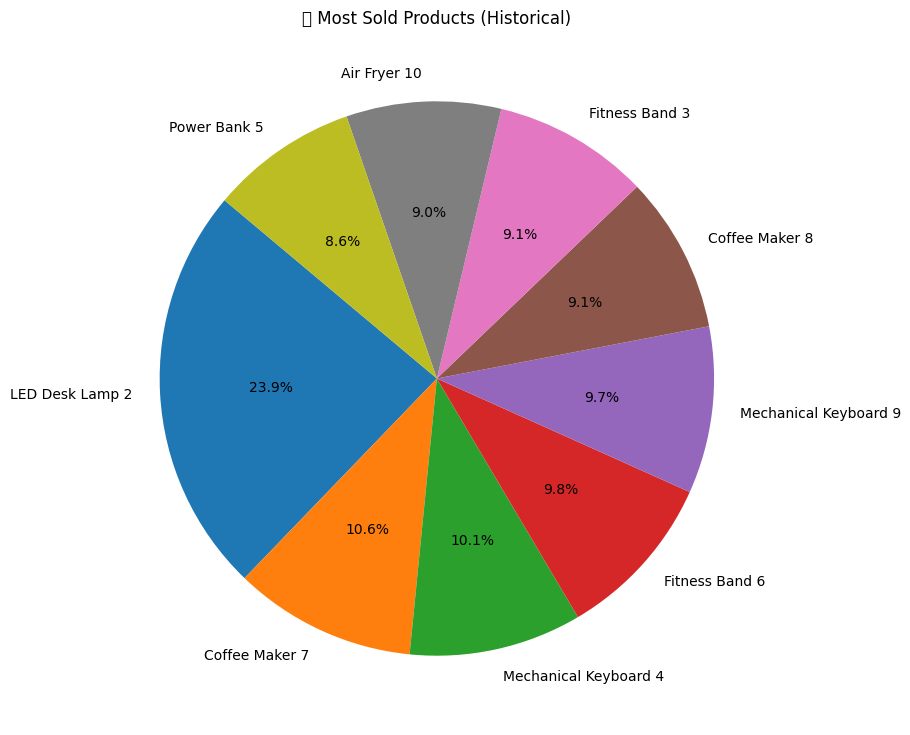

In [84]:
plt.figure(figsize=(9,9))
plt.pie(
    top_products['quantity'],
    labels=top_products['product_name'],
    autopct='%1.1f%%',
    startangle=140
)
plt.title("🛒 Most Sold Products (Historical)")
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128722 (\N{SHOPPING TROLLEY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


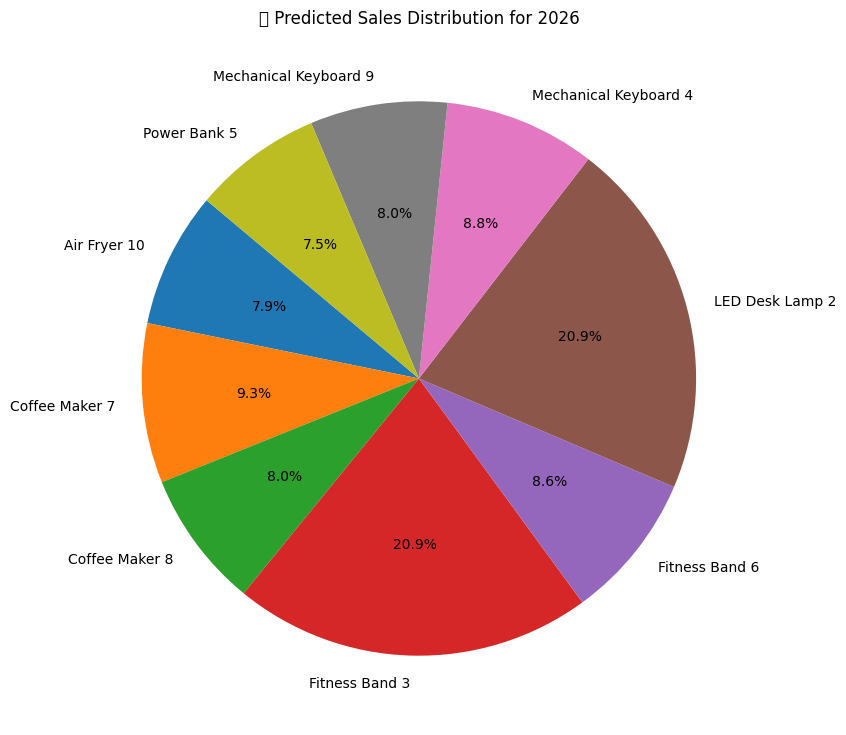

In [85]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib # Import joblib for loading the model

# Ensure `df` is available, as it's used for product_id_to_name mapping
# Assuming `df` is already loaded from previous steps.

# Ensure product_id_to_name mapping is available
if 'product_id_to_name' not in globals():
    product_id_to_name = df[['product_id', 'product_name']].drop_duplicates().set_index('product_id')['product_name'].to_dict()

# Ensure monthly_sales is defined, as it's used to get unique product_ids
if 'monthly_sales' not in globals() or monthly_sales.empty:
    monthly_sales = df.groupby(
        ['year', 'month', 'product_id']
    ).agg(
        units_sold=('quantity', 'sum')
    ).reset_index()

# Ensure predict_product_sales function is defined and model is available
if 'predict_product_sales' not in globals():
    print("Attempting to define `predict_product_sales` and load `model` if not found.")
    if 'model' not in globals():
        try:
            model = joblib.load("sales_forecast_model.pkl")
            print("✅ Model reloaded successfully within this cell.")
        except FileNotFoundError:
            print("Error: 'sales_forecast_model.pkl' not found. Please ensure STEP 13 was executed to save the model.")
            model = None # Set model to None to avoid further errors

    if model is not None:
        def predict_product_sales(product_id, year):
            future = pd.DataFrame({
                'year': [year] * 12,
                'month': list(range(1, 13)),
                'product_id': [product_id] * 12
            })
            future['predicted_units'] = model.predict(future)
            return future
        print("✅ `predict_product_sales` function defined within this cell.")
    else:
        print("Error: `model` is not defined. Cannot define `predict_product_sales`.")

# Re-create all_predictions if it's not defined or empty
if 'all_predictions' not in globals() or all_predictions.empty:
    all_predictions = pd.DataFrame()
    unique_product_ids = monthly_sales['product_id'].unique()
    if 'predict_product_sales' in globals() and model is not None:
        for product_id in unique_product_ids:
            product_prediction = predict_product_sales(product_id=product_id, year=2026)
            product_prediction['product_name'] = product_id_to_name.get(product_id, f"Unknown Product ({product_id})")
            all_predictions = pd.concat([all_predictions, product_prediction], ignore_index=True)
    else:
        print("Skipping predictions as `predict_product_sales` is not defined or model is not loaded.")

# Calculate total predicted sales for each product, only if all_predictions is not empty
if not all_predictions.empty:
    total_predicted_sales_2026 = all_predictions.groupby('product_name')['predicted_units'].sum().reset_index()

    plt.figure(figsize=(9, 9))
    plt.pie(
        total_predicted_sales_2026['predicted_units'],
        labels=total_predicted_sales_2026['product_name'],
        autopct='%1.1f%%',
        startangle=140
    )
    plt.title("🛒 Predicted Sales Distribution for 2026")
    plt.show()
else:
    print("Cannot plot predicted sales distribution because `all_predictions` is empty.")


STEP 9 — MONTHLY SALES PER PRODUCT

In [86]:
monthly_sales = df.groupby(
    ['year', 'month', 'product_id']
).agg(
    units_sold=('quantity', 'sum')
).reset_index()

monthly_sales.head()

,year,month,product_id,units_sold
0,2025,12,0,4352
1,2025,12,1,1657
2,2025,12,2,1833
3,2025,12,3,1566
4,2025,12,4,1781


STEP 10 — TRAIN / TEST SPLIT

In [87]:
X = monthly_sales[['year', 'month', 'product_id']]
y = monthly_sales['units_sold']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

STEP 11 — TRAIN XGBOOST MODEL

In [88]:
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

STEP 12 — MODEL EVALUATION

In [89]:
y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R² Score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

MAE: 1400.9136962890625
RMSE: 1906.384470666922
R² Score: -1098.2216796875
Mean Squared Error: 3634301.75


STEP 13 — SAVE MODEL (PRODUCTION READY)

In [90]:
joblib.dump(model, BASE_PATH + "sales_forecast_model.pkl")
print("✅ Model saved")

✅ Model saved


STEP 14 — LOAD MODEL ANYTIME (REUSE)

In [91]:
model = joblib.load(BASE_PATH + "sales_forecast_model.pkl")
print("✅ Model reloaded successfully")

✅ Model reloaded successfully


STEP 15 — FUTURE SALES FORECAST (PER PRODUCT)

In [92]:
def predict_product_sales(product_id, year):
    future = pd.DataFrame({
        'year': [year] * 12,
        'month': list(range(1, 13)),
        'product_id': [product_id] * 12
    })
    future['predicted_units'] = model.predict(future)
    return future

STEP 16 — MONTHLY BAR CHART (PREDICTION)

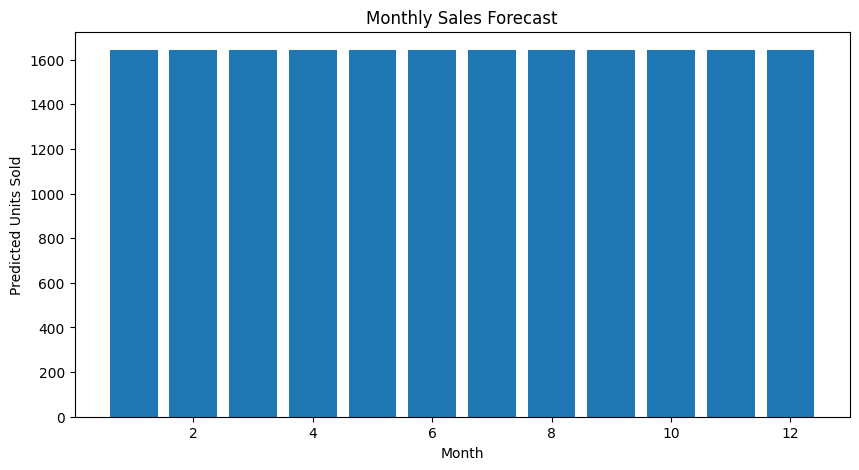

In [93]:
prediction = predict_product_sales(product_id=101, year=2026)

plt.figure(figsize=(10,5))
plt.bar(prediction['month'], prediction['predicted_units'])
plt.xlabel("Month")
plt.ylabel("Predicted Units Sold")
plt.title("Monthly Sales Forecast")
plt.show()

In [94]:
# Conceptual example of how monthly_sales would look with more data
# (This code is for demonstration and cannot be executed without actual extended historical data)

hypothetical_monthly_sales = pd.DataFrame({
    'year': [
        2023, 2023, 2023, 2023, 2023, 2023, 2023, 2023, 2023, 2023, 2023, 2023,
        2024, 2024, 2024, 2024, 2024, 2024, 2024, 2024, 2024, 2024, 2024, 2024,
        2025, 2025, 2025, 2025, 2025, 2025, 2025, 2025, 2025, 2025, 2025, 2025
    ],
    'month': [
        1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
        1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
        1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12
    ],
    'product_id': [2] * 36, # Example for product_id 2
    'units_sold': [
        1000, 1100, 1200, 1050, 1300, 1400, 1250, 1350, 1500, 1600, 1700, 1800,
        1100, 1200, 1300, 1150, 1400, 1500, 1350, 1450, 1600, 1700, 1800, 1900,
        1200, 1300, 1400, 1250, 1500, 1600, 1450, 1550, 1700, 1800, 1900, 2000 # Assuming current data has 2000 for Dec 2025
    ]
})

display(hypothetical_monthly_sales.head())
display(hypothetical_monthly_sales.tail())

print("\nWith such historical data, the model can learn patterns across months and years.")

,year,month,product_id,units_sold
0,2023,1,2,1000
1,2023,2,2,1100
2,2023,3,2,1200
3,2023,4,2,1050
4,2023,5,2,1300


,year,month,product_id,units_sold
31,2025,8,2,1550
32,2025,9,2,1700
33,2025,10,2,1800
34,2025,11,2,1900
35,2025,12,2,2000



With such historical data, the model can learn patterns across months and years.


### 4. Retraining the Model

Once you have a `monthly_sales` DataFrame with rich historical data, you would retrain your `XGBRegressor` model (`STEP 11`). The model would then be able to identify and utilize monthly and yearly trends, leading to more dynamic and accurate predictions for future months, rather than simply projecting a constant value.

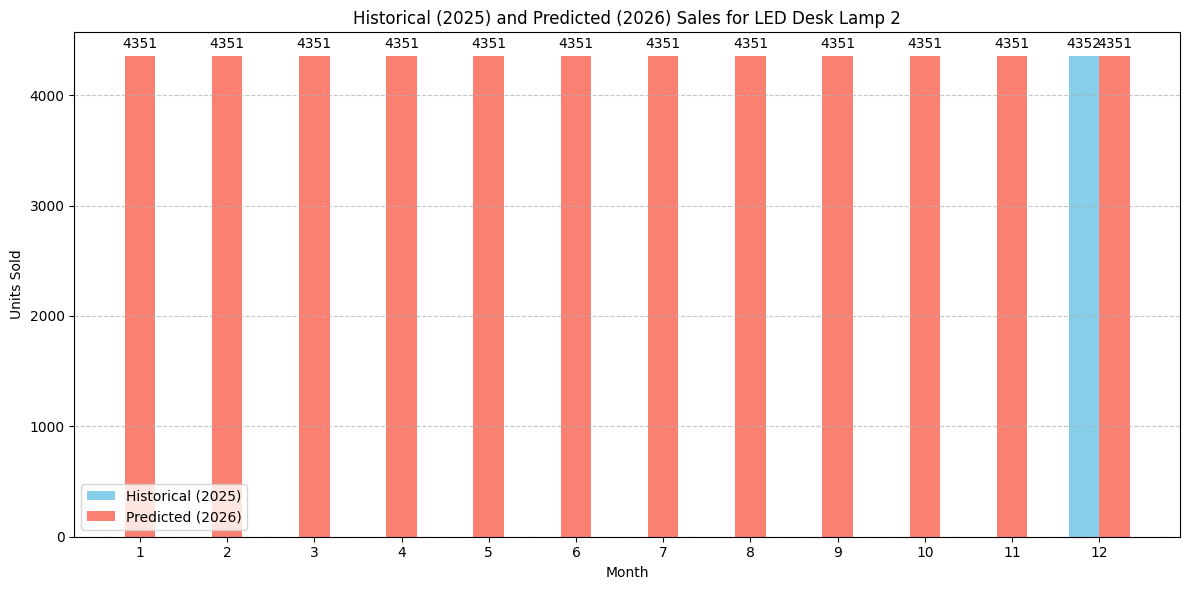

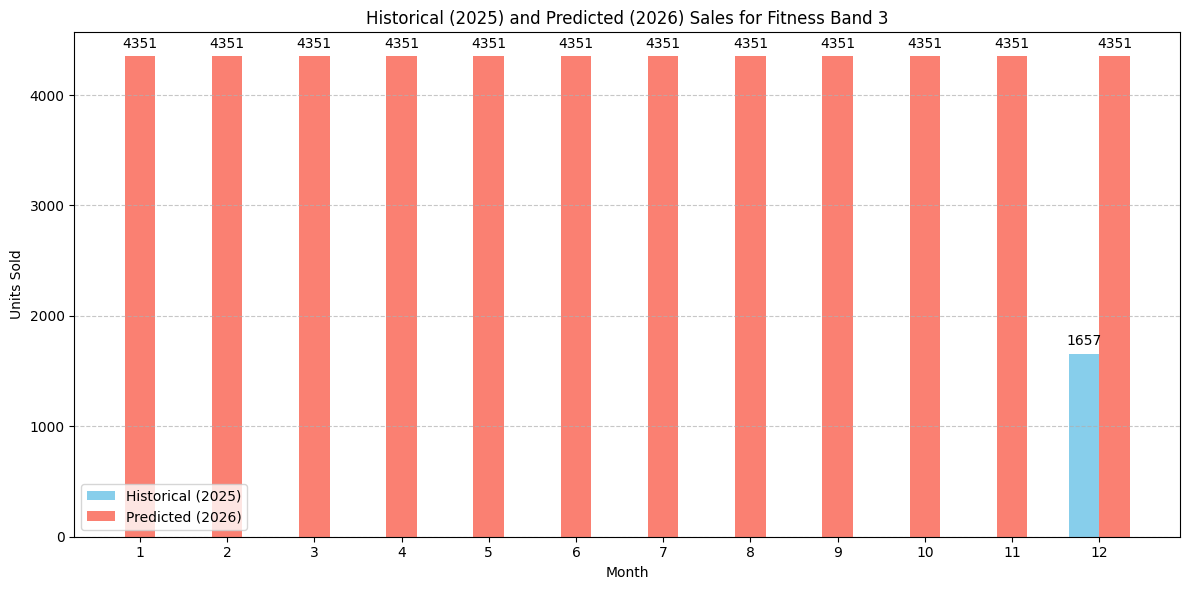

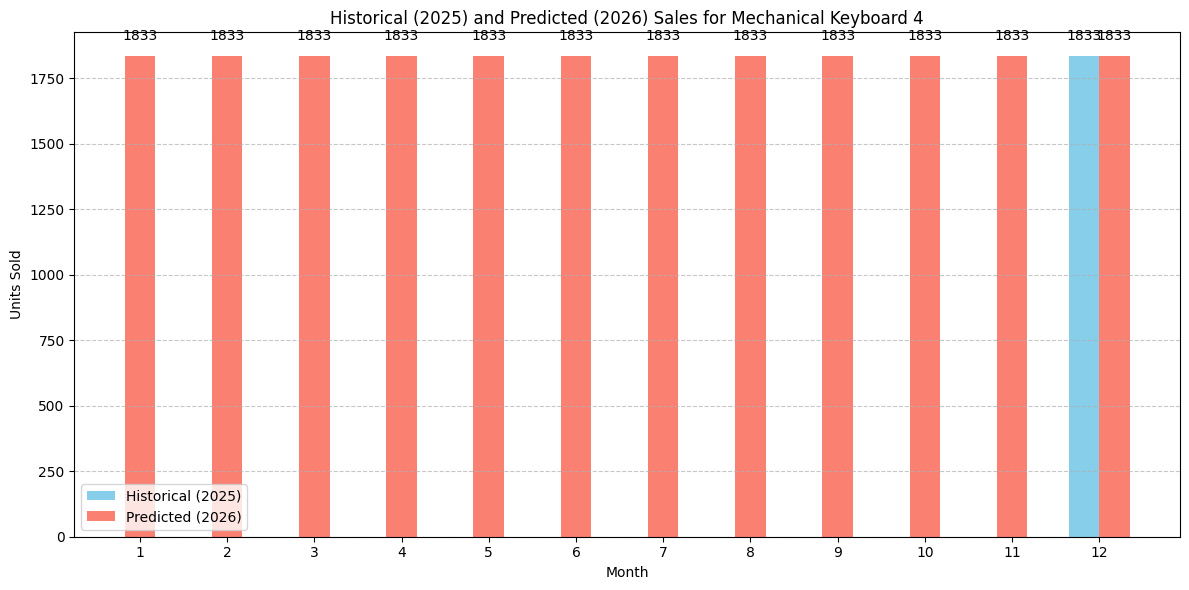

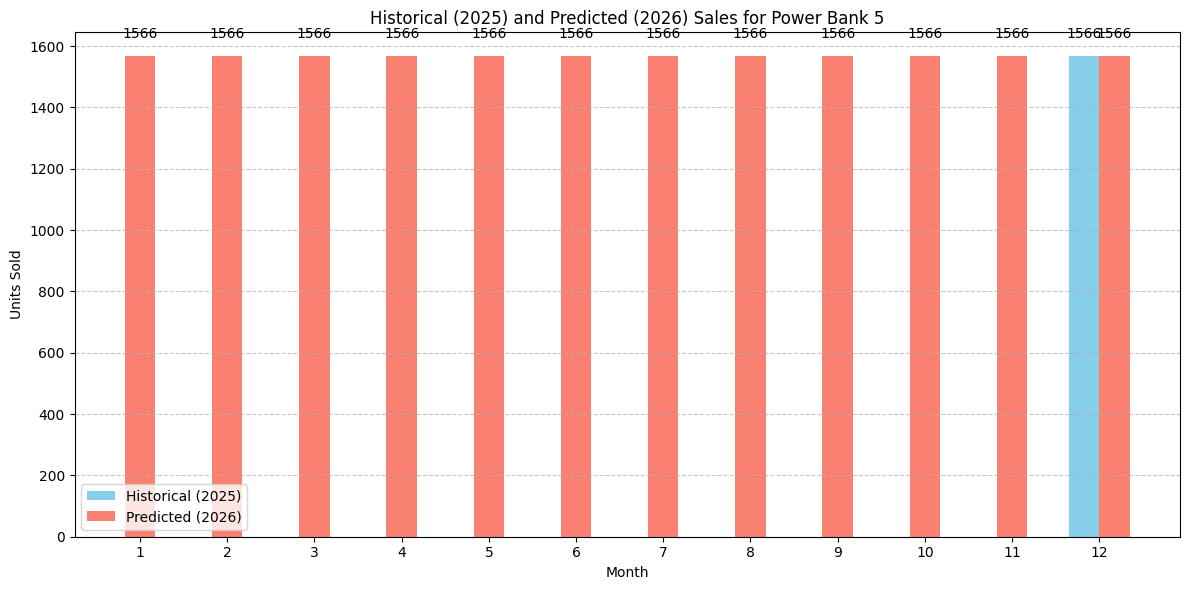

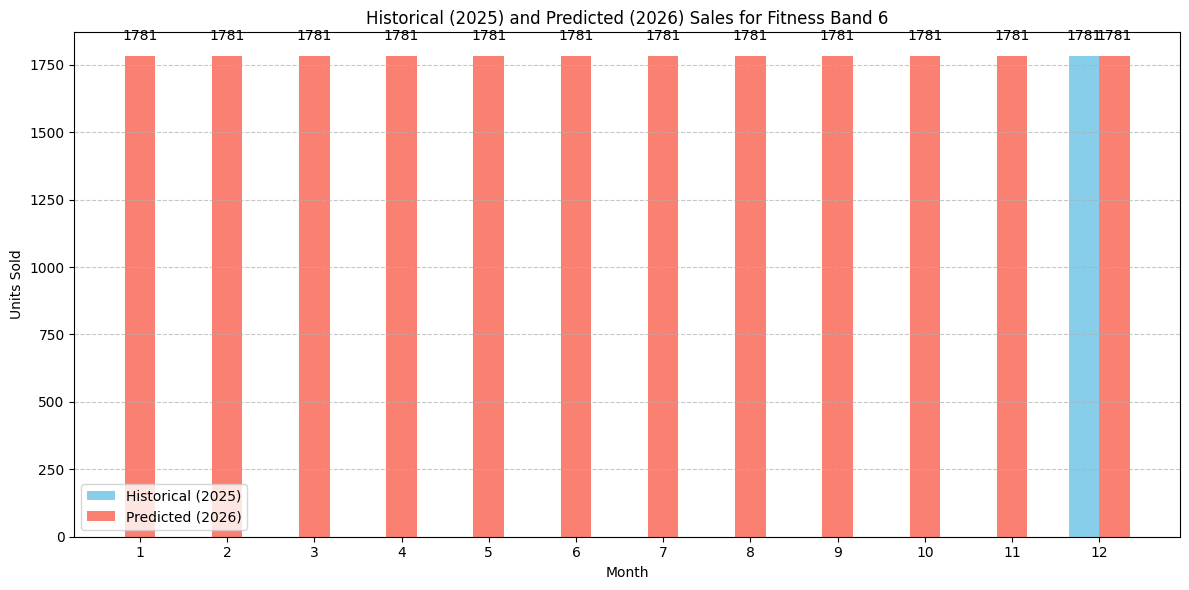

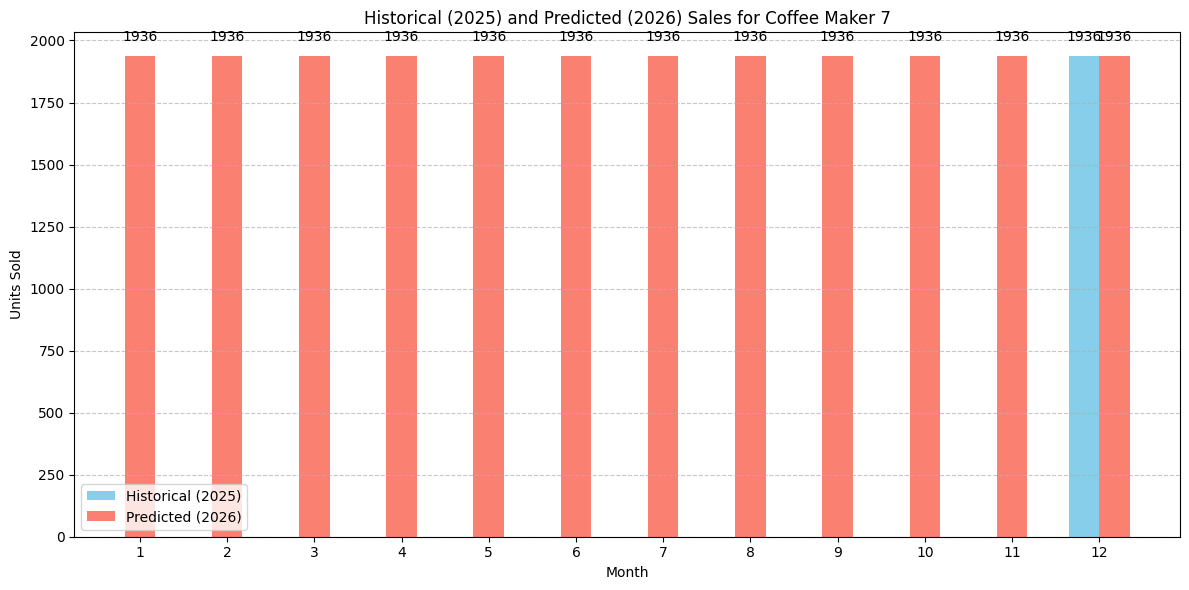

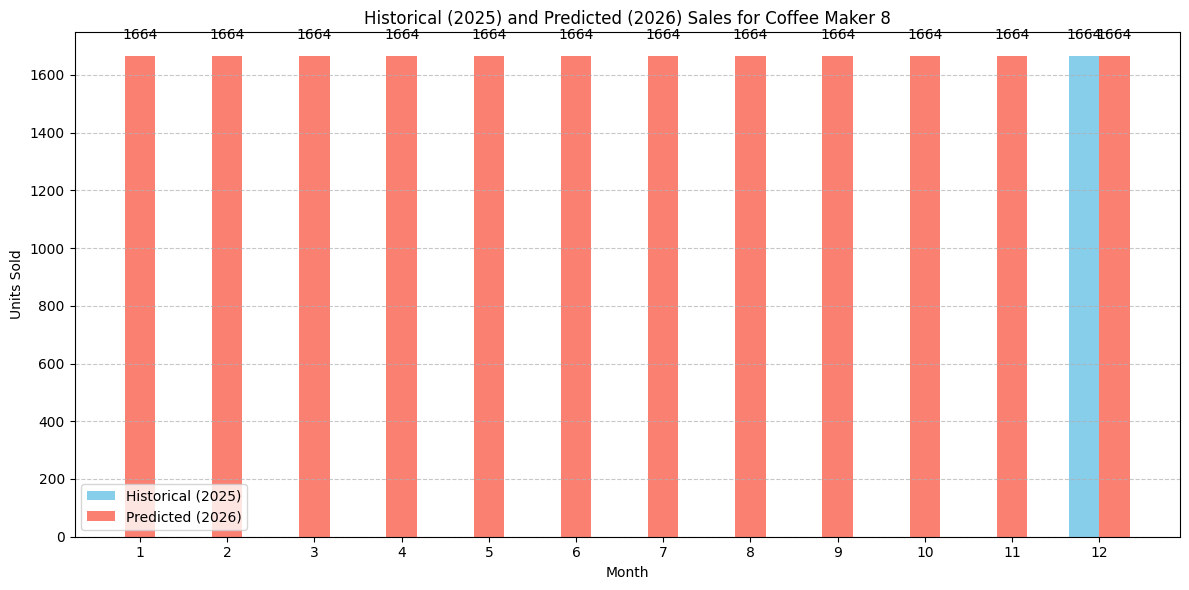

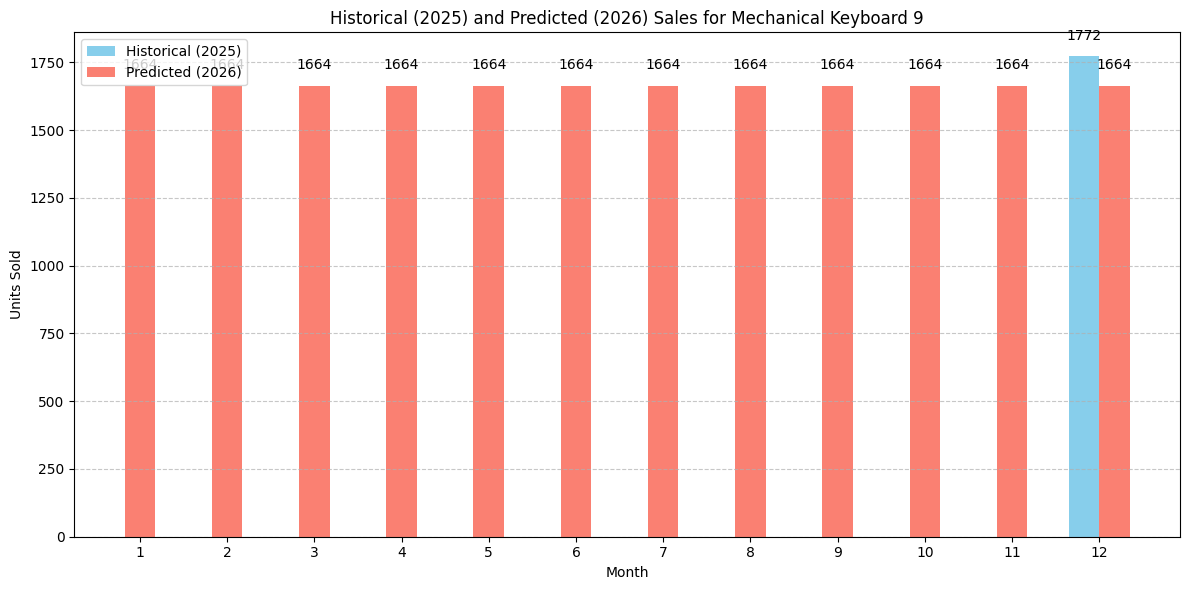

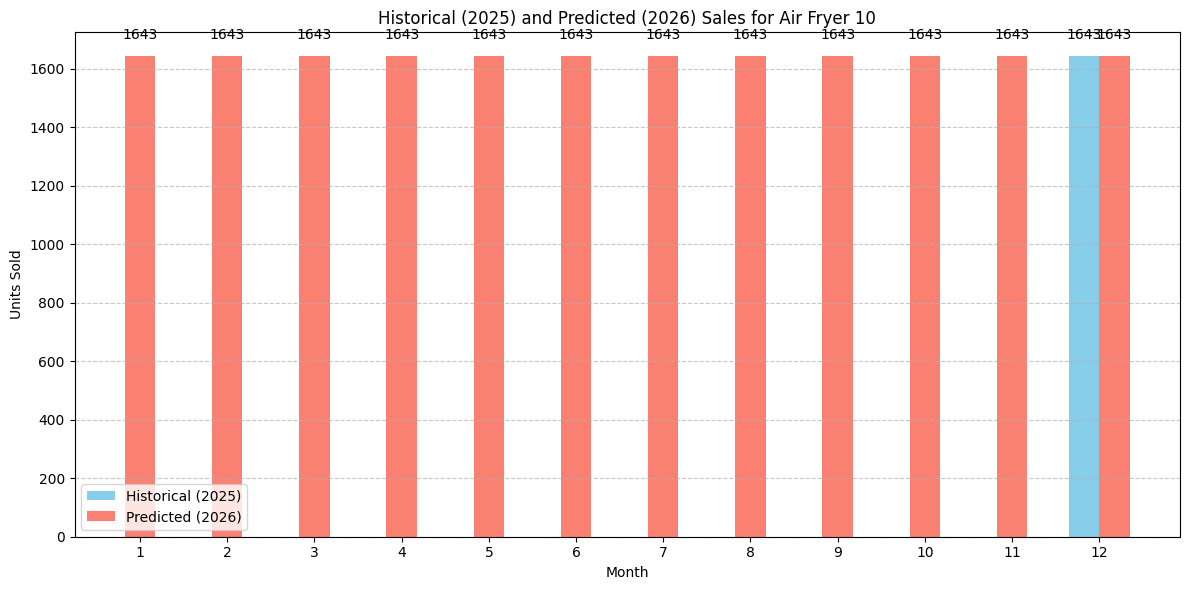

In [95]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import seaborn as sns # Ensure seaborn is imported for lineplot
import numpy as np # Import numpy for arange

# Ensure product_id_to_name mapping is available (if not already defined globally)
if 'product_id_to_name' not in globals():
    product_id_to_name = df[['product_id', 'product_name']].drop_duplicates().set_index('product_id')['product_name'].to_dict()

# Ensure monthly_sales is defined
if 'monthly_sales' not in globals() or monthly_sales.empty:
    monthly_sales = df.groupby(
        ['year', 'month', 'product_id']
    ).agg(
        units_sold=('quantity', 'sum')
    ).reset_index()

# Ensure predict_product_sales function is available, or define it here for robustness
if 'predict_product_sales' not in globals():
    # Attempt to load model if not already loaded
    if 'model' not in globals():
        try:
            model = joblib.load(BASE_PATH + "sales_forecast_model.pkl")
            print("✅ Model reloaded successfully for plotting.")
        except FileNotFoundError:
            print("Error: 'sales_forecast_model.pkl' not found. Cannot proceed with predictions.")
            model = None

    if model is not None:
        def predict_product_sales(product_id, year):
            future = pd.DataFrame({
                'year': [year] * 12,
                'month': list(range(1, 13)),
                'product_id': [product_id] * 12
            })
            future['predicted_units'] = model.predict(future)
            return future
        print("✅ `predict_product_sales` function defined for plotting.")
    else:
        print("Model not available, skipping `predict_product_sales` definition.")


if 'predict_product_sales' in globals() and model is not None:
    unique_product_ids = monthly_sales['product_id'].unique()
    bar_width = 0.35 # Define bar width for side-by-side plotting

    for product_id in unique_product_ids:
        product_name = product_id_to_name.get(product_id, f"Unknown Product ({product_id})")

        # Get predicted sales for 2026
        predicted_sales_2026 = predict_product_sales(product_id=product_id, year=2026)

        # Get historical sales for the latest year available in monthly_sales (2025 in this case)
        historical_sales_2025 = monthly_sales[
            (monthly_sales['product_id'] == product_id) & (monthly_sales['year'] == 2025)
        ]

        plt.figure(figsize=(12, 6))

        # X-axis for months
        months_labels = np.arange(1, 13)

        # Prepare x-positions for predicted bars
        predicted_months_x = np.array(predicted_sales_2026['month'], dtype=float)

        # Check if December historical data exists for this product
        has_dec_historical = not historical_sales_2025.empty and (historical_sales_2025['month'] == 12).any()

        if has_dec_historical:
            # Shift predicted December bar to the right
            predicted_months_x[predicted_months_x == 12] += bar_width/2
            # Plot historical December bar to the left
            hist_dec_month = historical_sales_2025['month'].iloc[0]
            hist_dec_units = historical_sales_2025['units_sold'].iloc[0]
            plt.bar(
                hist_dec_month - bar_width/2,
                hist_dec_units,
                label='Historical (2025)',
                color='skyblue',
                width=bar_width
            )
            plt.text(hist_dec_month - bar_width/2, hist_dec_units + 50, f'{hist_dec_units:.0f}', ha='center', va='bottom')


        # Plot all predicted bars
        bars_predicted = plt.bar(
            predicted_months_x,
            predicted_sales_2026['predicted_units'],
            label='Predicted (2026)',
            color='salmon',
            width=bar_width
        )
        # Add text labels for predicted bars
        for bar in bars_predicted:
            yval = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2, yval + 50, f'{yval:.0f}', ha='center', va='bottom')


        plt.title(f"Historical (2025) and Predicted (2026) Sales for {product_name}")
        plt.xlabel("Month")
        plt.ylabel("Units Sold")
        plt.xticks(months_labels)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.legend()
        plt.tight_layout()
        plt.show()
else:
    print("Skipping plots as `predict_product_sales` is not defined or model is not loaded.")